<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Testing out Indicators across various Stocks to Validate
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

# Import Packages

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime
import os
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.formula.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import yfinance as yf
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators
import Measurement

# Grab Data for Ticker

In [2]:
tickers = Indicators.save_sp500_tickers()
ticker = tickers[0]
ticker = 'PBR'
#ticker = 'WDC'
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
df = Indicators.get_ticker(ticker,500)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker
0,2022-04-07 09:30:00-04:00,14.9200,15.215000,14.920,15.0600,8503672,0.0,0.0,2022-04-07 09:30:00,PBR
1,2022-04-07 10:30:00-04:00,15.0553,15.145000,15.035,15.0500,2793440,0.0,0.0,2022-04-07 10:30:00,PBR
2,2022-04-07 11:30:00-04:00,15.0500,15.060000,14.950,15.0466,2532118,0.0,0.0,2022-04-07 11:30:00,PBR
3,2022-04-07 12:30:00-04:00,15.0500,15.170000,14.990,15.1400,2041449,0.0,0.0,2022-04-07 12:30:00,PBR
4,2022-04-07 13:30:00-04:00,15.1400,15.340000,15.140,15.3233,2984410,0.0,0.0,2022-04-07 13:30:00,PBR
...,...,...,...,...,...,...,...,...,...,...
3480,2024-04-03 12:30:00-04:00,15.4550,15.560000,15.445,15.5500,1570709,0.0,0.0,2024-04-03 12:30:00,PBR
3481,2024-04-03 13:30:00-04:00,15.5500,15.620000,15.545,15.5700,1241350,0.0,0.0,2024-04-03 13:30:00,PBR
3482,2024-04-03 14:30:00-04:00,15.5699,15.590000,15.550,15.5550,1143053,0.0,0.0,2024-04-03 14:30:00,PBR
3483,2024-04-03 15:30:00-04:00,15.5550,15.610000,15.530,15.5950,1876424,0.0,0.0,2024-04-03 15:30:00,PBR


# Add SMA, Min/Max, Events

In [3]:
SMAs = [5,30,60,90]
smoothing = 7
window = 7

df = Indicators.get_sma(df,SMAs)
events_df = {}
minmax = Indicators.get_max_min(df, smoothing, window)
for event in events:
    events_df[event] = getattr(Indicators,event)(minmax)
#hs = Indicators.find_HS(minmax).reset_index(drop=True)
#invhs = Indicators.find_IHS(minmax).reset_index(drop=True)
#rw = Indicators.find_RW(minmax,.03).reset_index(drop=True)
#fw = Indicators.find_FW(minmax,.03).reset_index(drop=True)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,SMA5,SMA30,SMA60,SMA90
0,2022-04-07 09:30:00-04:00,14.9200,15.215000,14.920,15.0600,8503672,0.0,0.0,2022-04-07 09:30:00,PBR,NaN,NaN,NaN,NaN
1,2022-04-07 10:30:00-04:00,15.0553,15.145000,15.035,15.0500,2793440,0.0,0.0,2022-04-07 10:30:00,PBR,NaN,NaN,NaN,NaN
2,2022-04-07 11:30:00-04:00,15.0500,15.060000,14.950,15.0466,2532118,0.0,0.0,2022-04-07 11:30:00,PBR,NaN,NaN,NaN,NaN
3,2022-04-07 12:30:00-04:00,15.0500,15.170000,14.990,15.1400,2041449,0.0,0.0,2022-04-07 12:30:00,PBR,NaN,NaN,NaN,NaN
4,2022-04-07 13:30:00-04:00,15.1400,15.340000,15.140,15.3233,2984410,0.0,0.0,2022-04-07 13:30:00,PBR,15.12398,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3480,2024-04-03 12:30:00-04:00,15.4550,15.560000,15.445,15.5500,1570709,0.0,0.0,2024-04-03 12:30:00,PBR,15.50300,15.246507,15.011985,14.887997
3481,2024-04-03 13:30:00-04:00,15.5500,15.620000,15.545,15.5700,1241350,0.0,0.0,2024-04-03 13:30:00,PBR,15.49300,15.270007,15.024068,14.898274
3482,2024-04-03 14:30:00-04:00,15.5699,15.590000,15.550,15.5550,1143053,0.0,0.0,2024-04-03 14:30:00,PBR,15.51400,15.293007,15.038068,14.907441
3483,2024-04-03 15:30:00-04:00,15.5550,15.610000,15.530,15.5950,1876424,0.0,0.0,2024-04-03 15:30:00,PBR,15.54500,15.315507,15.053402,14.918219


# Plot Data

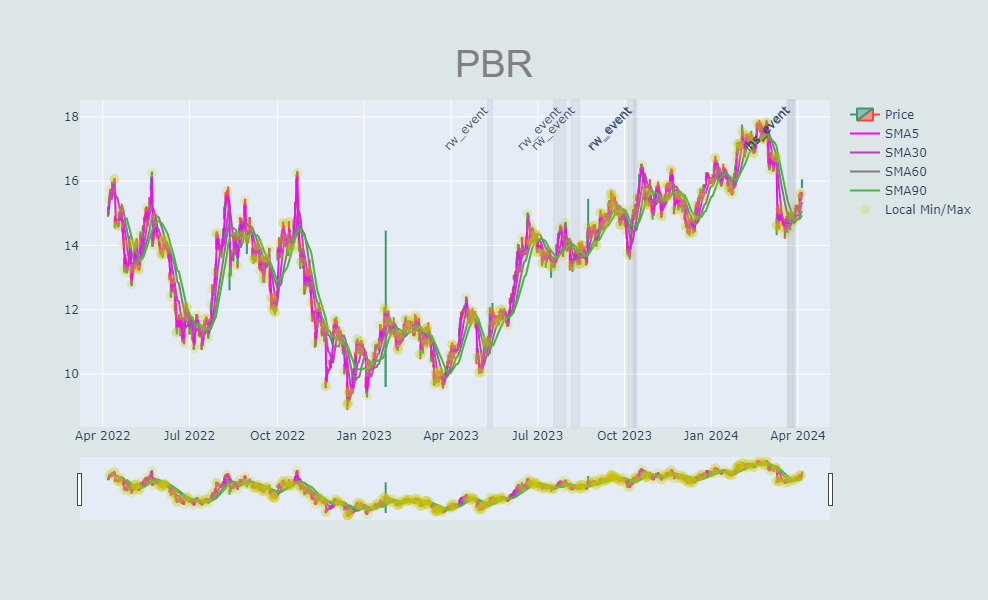

In [4]:
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=df['date'],
                open=df['open'],
                high=df['high'],
                low=df['low'],
                close=df['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=df['date'],
                y=df['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax['date'],
                y=minmax['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.2)
                        ))
# iterate through the shaded regions dataframe
for event in events:
    for index, row in events_df[event].iterrows():
    
        # retrieve the dates
        start = row['start_event']
        end = row['end_event']

        # add shaded region
        fig.add_vrect(
            x0=start,
            x1=end,
            fillcolor="grey",
            opacity=0.1,
            line_width=1,
            annotation_text=event,
            annotation_textangle=-45
        )   
 
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

# Zoom in on Specific Event

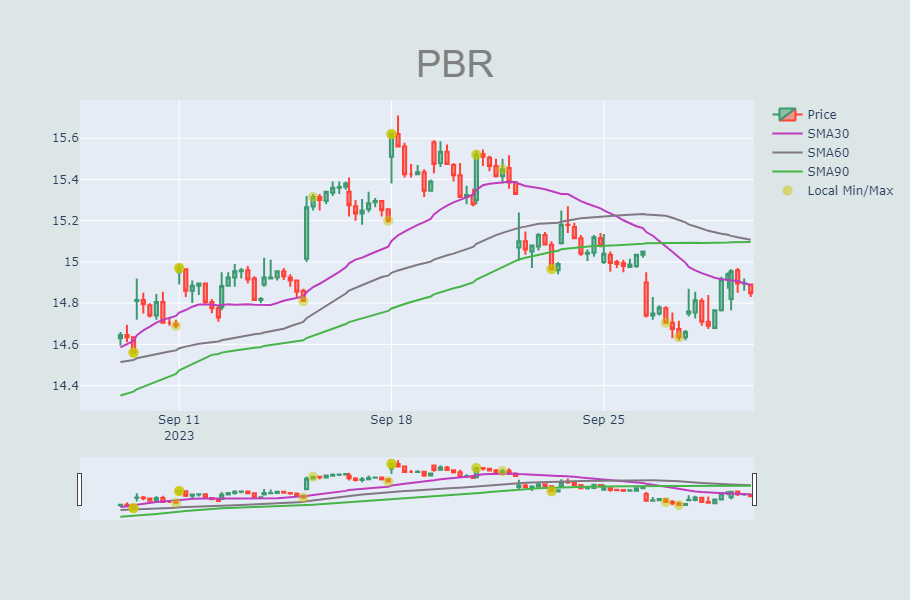

In [46]:
df2 = Indicators.main(ticker,500,SMAs,smoothing,window)
eventType = 'rw_event'
ID = list(df2[df2.date==df2[df2[eventType]==1].date.min()].index)[0]
chartdf = df2.iloc[ID-10:ID+95].copy()
minmax2 = minmax[(minmax.date>=chartdf.date.min())&(minmax.date<=chartdf.date.max())].copy()
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=chartdf['date'],
                open=chartdf['open'],
                high=chartdf['high'],
                low=chartdf['low'],
                close=chartdf['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=chartdf['date'],
                y=chartdf['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax2['date'],
                y=minmax2['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.5)
                        ))
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

# Build Inidcators and Group by Change During Event

In [5]:
M = 80
K = 500
window = 7
smoothing = 7
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}


df3 = Measurement.combine_events(tickers,events,SMAs,smoothing,window,M,K)
df3.reset_index(inplace=True,drop=True)
event = 'fw_event'
df3.groupby(['ticker',event + '_start_time',event + '_end_time']).agg({'volume':'size',event:'mean'}).reset_index().head(20)

BRK.B: No data found, symbol may be delisted
'DataFrame' object has no attribute 'Datetime'
BF.B: Period '500d' is invalid, must be one of ['1mo', '3mo', '6mo', 'ytd', '1y', '2y', '5y', '10y', 'max']
'DataFrame' object has no attribute 'Datetime'


,ticker,fw_event_start_time,fw_event_end_time,volume,fw_event
0,A,2022-04-07 09:30:00,2023-02-07 13:30:00,1510,0.0
1,A,2023-02-07 14:30:00,2023-02-21 11:30:00,61,1.0
2,A,2023-02-21 12:30:00,2023-09-13 10:30:00,983,0.0
3,A,2023-09-13 11:30:00,2023-09-21 15:30:00,47,1.0
4,A,2023-09-22 09:30:00,2024-04-04 09:30:00,929,0.0
5,AAL,2022-04-07 09:30:00,2022-05-03 13:30:00,124,0.0
6,AAL,2022-05-03 14:30:00,2022-05-12 13:30:00,49,1.0
7,AAL,2022-05-12 14:30:00,2023-07-26 15:30:00,2103,0.0
8,AAL,2023-07-27 09:30:00,2023-08-07 10:30:00,51,1.0
9,AAL,2023-08-07 11:30:00,2023-09-08 13:30:00,164,0.0


In [6]:
event = 'fw_event'
df3.groupby(['ticker',event + '_start_time',event + '_end_time']).agg({'volume':'size',event:'mean'}).reset_index().head(20)

,ticker,fw_event_start_time,fw_event_end_time,volume,fw_event
0,A,2022-04-07 09:30:00,2023-02-07 13:30:00,1510,0.0
1,A,2023-02-07 14:30:00,2023-02-21 11:30:00,61,1.0
2,A,2023-02-21 12:30:00,2023-09-13 10:30:00,983,0.0
3,A,2023-09-13 11:30:00,2023-09-21 15:30:00,47,1.0
4,A,2023-09-22 09:30:00,2024-04-04 09:30:00,929,0.0
5,AAL,2022-04-07 09:30:00,2022-05-03 13:30:00,124,0.0
6,AAL,2022-05-03 14:30:00,2022-05-12 13:30:00,49,1.0
7,AAL,2022-05-12 14:30:00,2023-07-26 15:30:00,2103,0.0
8,AAL,2023-07-27 09:30:00,2023-08-07 10:30:00,51,1.0
9,AAL,2023-08-07 11:30:00,2023-09-08 13:30:00,164,0.0


In [7]:
final4 = Measurement.get_totals(df3,events)
final4.reset_index(inplace=True)
#final4['50%-2'] = pd.Series(["{0:.2f}%".format(val * 100) for val in final4['50%-2']], index = final4.index)
#final4['50%0'] = pd.Series(["{0:.2f}%".format(val * 100) for val in final4['50%0']], index = final4.index)
#final4.reset_index(inplace=True)
eventSuccess = final4.groupby('event')['Indicator'].mean(). \
            reset_index(). \
            rename(columns={'Indicator':'event_success'})
stockSuccess = final4.groupby(['event','ticker']). \
            agg({'Indicator':'mean','after_event_observations':'sum'}). \
            reset_index(). \
            rename(columns={'Indicator':'stock_success','after_event_observations':'event_count'})
totalSuccess = eventSuccess.merge(stockSuccess, on = ['event'])
totalSuccess = totalSuccess[['event','ticker','event_count','event_success','stock_success']]
#totalSuccess['event_success'] = pd.Series(["{0:.2f}%".format(val * 100) for val in totalSuccess['event_success']], 
#            index = totalSuccess.index)
#totalSuccess['stock_success'] = pd.Series(["{0:.2f}%".format(val * 100) for val in totalSuccess['stock_success']], 
#            index = totalSuccess.index)
final4 = final4.merge(totalSuccess, on = ['event','ticker'])
#print('Percentage of Success: <br>{}'.format(totalSuccess.head(10)))
#print(final4.date.min())
final4

,index,ticker,event,event_observations,event_start_time,event_end_time,after_event_observations,after_event_mean,after_event_start_time,after_event_end_time,count,mean,min,median,max,Indicator,event_count,event_success,stock_success
0,0,A,rw_event,133.0,2022-07-15 15:30:00,2022-08-03 11:30:00,1.0,-0.045636,2022-08-03 11:30:00,2022-08-18 13:30:00,2037.0,-0.046341,-0.165649,-0.037669,0.034253,1,4.0,0.499741,1.0
1,1,A,rw_event,46.0,2023-04-04 12:30:00,2023-04-13 15:30:00,1.0,-0.095060,2023-04-13 15:30:00,2023-05-01 10:30:00,2037.0,-0.046341,-0.165649,-0.037669,0.034253,1,4.0,0.499741,1.0
2,2,A,rw_event,36.0,2023-10-31 14:30:00,2023-11-07 14:30:00,1.0,-0.050012,2023-11-07 14:30:00,2023-11-24 09:30:00,2037.0,-0.046341,-0.165649,-0.037669,0.034253,1,4.0,0.499741,1.0
3,3,A,rw_event,51.0,2023-12-11 10:30:00,2023-12-20 11:30:00,1.0,-0.088146,2023-12-20 11:30:00,2024-01-08 13:30:00,2037.0,-0.046341,-0.165649,-0.037669,0.034253,1,4.0,0.499741,1.0
4,4,AAL,rw_event,23.0,2023-05-26 09:30:00,2023-06-01 10:30:00,1.0,-0.010526,2023-06-01 10:30:00,2023-06-16 12:30:00,2282.0,-0.076461,-0.486318,-0.061551,0.037932,0,2.0,0.499741,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7548,2099,ZBRA,ihs_event,44.0,2022-12-19 13:30:00,2022-12-28 14:30:00,1.0,0.184229,2022-12-28 14:30:00,2023-01-17 09:30:00,2436.0,0.063461,-0.146742,0.052683,0.218779,1,1.0,0.501901,1.0
7549,2100,ZTS,ihs_event,53.0,2023-04-20 14:30:00,2023-05-02 10:30:00,1.0,0.055753,2023-05-02 10:30:00,2023-05-17 12:30:00,1951.0,0.046391,-0.009409,0.037109,0.266723,1,4.0,0.501901,0.5
7550,2101,ZTS,ihs_event,33.0,2023-09-14 12:30:00,2023-09-21 09:30:00,1.0,-0.005281,2023-09-21 09:30:00,2023-10-06 11:30:00,1951.0,0.046391,-0.009409,0.037109,0.266723,0,4.0,0.501901,0.5
7551,2102,ZTS,ihs_event,56.0,2023-11-22 09:30:00,2023-12-05 11:30:00,1.0,0.113034,2023-12-05 11:30:00,2023-12-20 13:30:00,1951.0,0.046391,-0.009409,0.037109,0.266723,1,4.0,0.501901,0.5


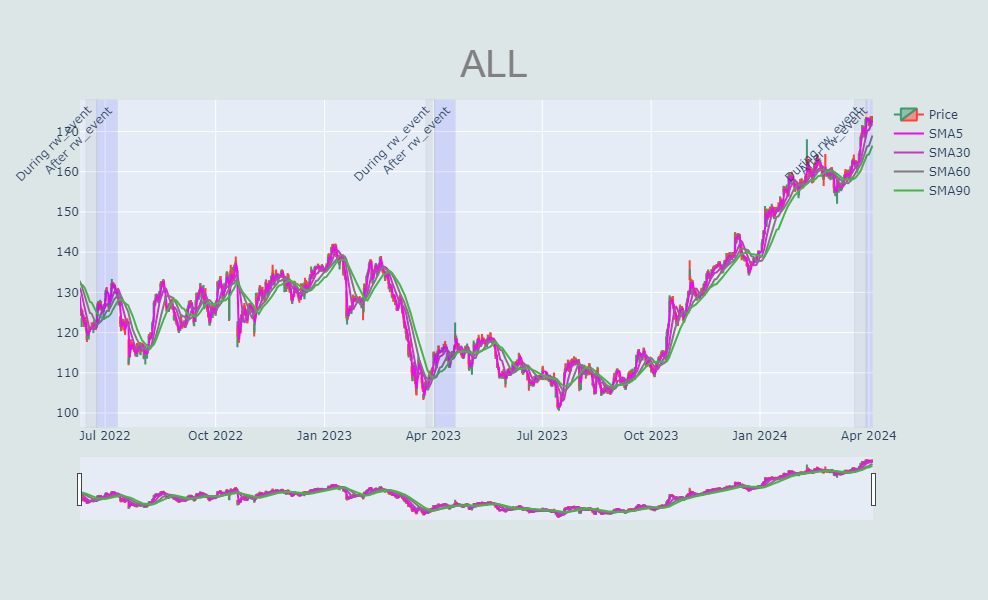

In [13]:
event = 'rw_event'
ticker = 'ALL'
#ticker = final4[final4.Indicator==1].ticker.sample(1).tolist()
#ticker = ticker[0]
df = df3[df3.ticker==ticker].copy()
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=df['date'],
                open=df['open'],
                high=df['high'],
                low=df['low'],
                close=df['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=df['date'],
                y=df['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
    
# iterate through the shaded regions dataframe
df[event] = np.where(df[event + '_after']==1,-1,df[event])
df[event+'_start_time'] = np.where(df[event + '_after']==1, df[event+'_start_time2'],df[event+'_start_time'])
df[event+'_end_time'] = np.where(df[event + '_after']==1, df[event+'_end_time2'],df[event+'_end_time'])
rw = df.groupby([event+'_start_time',event+'_end_time'])[event].mean().reset_index()
rw = rw[rw[event].isin([1,-1])].reset_index(drop=True)
eventName = {1:'During {}'.format(event),-1:'After {}'.format(event),0:'No {}'.format(event)}
eventList = list(rw[event])
eventList = [eventName.get(item,item)  for item in eventList]
for index, row in rw.iterrows():
    eventValue = eventList[index]
    # retrieve the dates
    if re.match('During .*',eventValue):
        fcolor = "grey"
    else:
        fcolor = "blue"
    start = row[event+'_start_time']
    end = row[event+'_end_time']
    # add shaded region
    fig.add_vrect(
            x0=start,
            x1=end,
            fillcolor=fcolor,
            opacity=0.1,
            line_width=1,
            annotation_text=eventValue,
            annotation_textangle=-45
        )  
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

In [11]:
from datetime import timedelta
final4[(abs(final4['after_event_mean']-final4['median']) > 0.04)&
      (final4['event_observations']> 10)&
      (pd.to_datetime(final4['after_event_end_time'])<(datetime.today()-timedelta(days=1)))].Indicator.describe()

count    1655.000000
mean        0.776435
std         0.416760
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Indicator, dtype: float64

In [53]:
final.sort_values(['event_end_time'],ascending=0).head(20)

,ticker,event,event_observations,event_start_time,event_end_time,after_event_observations,after_event_mean,after_event_start_time,after_event_end_time,count,mean,min,median,max,Indicator
1585,RTX,1,91.0,2024-03-11 14:30:00,2024-03-28 13:30:00,1.0,-0.007516,2024-03-28 13:30:00,2024-04-02 11:30:00,2007.0,-0.041447,-0.205567,-0.028123,0.045952,0
103,ALL,1,49.0,2024-03-19 12:30:00,2024-03-28 11:30:00,1.0,-0.011434,2024-03-28 11:30:00,2024-04-02 11:30:00,2150.0,-0.050095,-0.188048,-0.039584,0.013347,0
129,AMGN,1,48.0,2024-03-18 10:30:00,2024-03-26 15:30:00,1.0,-0.012416,2024-03-26 15:30:00,2024-04-02 11:30:00,1797.0,-0.039419,-0.156920,-0.030030,0.024530,0
119,AMD,1,52.0,2024-03-19 09:30:00,2024-03-26 11:30:00,1.0,-0.106009,2024-03-26 11:30:00,2024-04-02 11:30:00,2445.0,-0.075289,-0.361651,-0.056548,0.059274,1
1925,ZBRA,1,35.0,2024-03-19 10:30:00,2024-03-26 09:30:00,1.0,-0.014936,2024-03-26 09:30:00,2024-04-02 11:30:00,2410.0,-0.071979,-0.343896,-0.053646,0.049044,0
334,CEG,1,60.0,2024-03-13 13:30:00,2024-03-26 09:30:00,1.0,-0.011002,2024-03-26 09:30:00,2024-04-02 11:30:00,2129.0,-0.048224,-0.228985,-0.035581,0.019647,0
329,CE,1,115.0,2024-03-12 09:30:00,2024-03-26 09:30:00,1.0,-0.007789,2024-03-26 09:30:00,2024-04-02 11:30:00,2161.0,-0.067979,-0.364469,-0.048884,0.046703,0
1511,PYPL,1,78.0,2024-03-14 10:30:00,2024-03-26 09:30:00,1.0,-0.002964,2024-03-26 09:30:00,2024-04-02 11:30:00,2608.0,-0.084528,-0.362658,-0.065170,0.043049,0
1648,STZ,1,29.0,2024-03-19 15:30:00,2024-03-25 15:30:00,1.0,-0.007132,2024-03-25 15:30:00,2024-04-02 11:30:00,1817.0,-0.035843,-0.147113,-0.028658,0.016219,0
459,CTRA,1,50.0,2024-03-14 11:30:00,2024-03-25 11:30:00,1.0,-0.008034,2024-03-25 11:30:00,2024-04-02 11:30:00,1906.0,-0.057885,-0.273392,-0.051216,0.032543,0


In [12]:
final[(final['event_observations']> 10)&
      (pd.to_datetime(final['after_event_end_time'])<(datetime.today()-timedelta(days=1)))].Indicator.describe()

count    1771.000000
mean        0.525692
std         0.499481
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Indicator, dtype: float64

In [6]:
test = Indicators.main(ticker,events,K,SMAs,smoothing,window)
test

KeyError: 'ihs_event'